In [8]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split

In [10]:
insurance_data=pd.read_csv("insurance.csv")
X=insurance_data.drop(columns=["charges","region"])
y=insurance_data["charges"]
X["sex"]=X["sex"].map({"female":1,"male":0})
X["smoker"]=X["smoker"].map({"yes":1,"no":0})
X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


<Axes: >

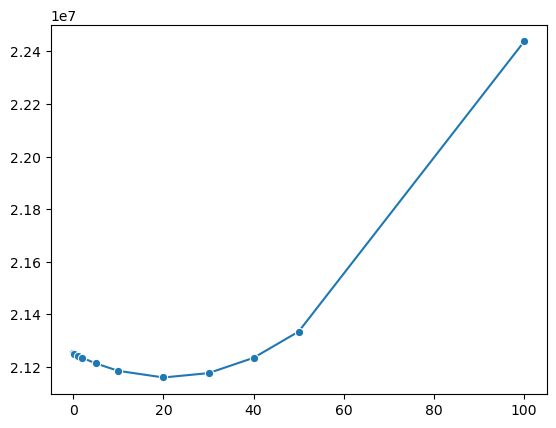

In [23]:
import seaborn as sns
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]

for a in alphas:

    
    lasso_model=Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    y_pred=lasso_model.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
   
    mses.append(mse)
sns.lineplot(x=alphas,y=mses,marker="o")

In [26]:
from sklearn.linear_model import LassoCV

alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]

lasso_cv_model=LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=100,
    random_state=42
)

lasso_cv_model.fit(X_train,y_train)

print("best alpha:",lasso_cv_model.alpha_)


best alpha: 0.001


C:\Users\Sivani\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3108718210.1984463, tolerance: 12420618.06944427
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Sivani\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 685238675.7466278, tolerance: 12420618.06944427
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Sivani\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 897177339.2319603, tolerance: 12420618.06944427
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Sivani\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:68